**Step 1: System Dynamics**

In [1]:
import torch

def system_dynamics(state_vector, control_input, mass, inertia, g):
    """
    Physics of the drone
    State_vector = [x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw]
    Control_input = [thrust, torque_roll, torque_pitch, torque_yaw]
    """
    # # Physical parameters definition REMEMBER TO ADJUST IF NECESSARY
    # g = 9.81  # gravity [m/s^2]
    # mass = 2.0  # mass of the drone [kg]
    # inertia = torch.tensor([0.0216, 0.0216, 0.04])  # inertia around roll (Ix), pitch (Iy), yaw (Iz) [kg*m^2]
    if not isinstance(inertia, torch.Tensor):
        inertia = torch.tensor(inertia)

    # Unpack state vector
    x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw = state_vector[:,0], state_vector[:,1], state_vector[:,2], state_vector[:,3], state_vector[:,4], state_vector[:,5], state_vector[:,6], state_vector[:,7], state_vector[:,8], state_vector[:,9], state_vector[:,10], state_vector[:,11]
    thrust, torque_roll, torque_pitch, torque_yaw = control_input[:,0], control_input[:,1], control_input[:,2], control_input[:,3]
    
    # # Move sin/cos components to torch tensors (if they aren't already) to be consistent with the rest of the states
    # if not isinstance(roll, torch.Tensor):
    #     roll = torch.tensor(roll)
    # if not isinstance(pitch, torch.Tensor):
    #     pitch = torch.tensor(pitch)
    # if not isinstance(yaw, torch.Tensor):
    #     yaw = torch.tensor(yaw)

    # NOTICE THAT: the dataset is recorded in the North-East-Down (NED) frame, so z is positive downwards. The system dynamics then must be consistent with this frame ( ==> vz_dot gravity is positive and thrust is negative)
    # Compute dynamics
    x_dot = vx # world frame
    y_dot = vy # world frame
    z_dot = vz # world frame
    roll_dot = w_roll + (torch.sin(roll) * torch.tan(pitch) * w_pitch) + (torch.cos(roll) * torch.tan(pitch) * w_yaw) # world frame
    pitch_dot = (torch.cos(roll) * w_pitch) - (torch.sin(roll) * w_yaw) # world frame
    yaw_dot = (torch.sin(roll) / torch.cos(pitch) * w_pitch) + (torch.cos(roll) / torch.cos(pitch) * w_yaw) # world frame
    vx_dot = (-thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.cos(yaw) + torch.sin(roll) * torch.sin(yaw)) # world frame
    vy_dot = (-thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.sin(yaw) - torch.sin(roll) * torch.cos(yaw)) # world frame
    vz_dot = g - (thrust / mass) * (torch.cos(roll) * torch.cos(pitch)) # world frame
    w_roll_dot = (inertia[1]-inertia[2]) / inertia[0] * w_pitch * w_yaw + torque_roll / inertia[0] # body frame
    w_pitch_dot = (inertia[2]-inertia[0]) / inertia[1] * w_roll * w_yaw + torque_pitch / inertia[1] # body frame
    w_yaw_dot = (inertia[0]-inertia[1]) / inertia[2] * w_roll * w_pitch + torque_yaw / inertia[2] # body frame

    state_vector_dot = torch.stack([x_dot, y_dot, z_dot,
                                  roll_dot, pitch_dot, yaw_dot,
                                  vx_dot, vy_dot, vz_dot,
                                  w_roll_dot, w_pitch_dot, w_yaw_dot], dim=1) 

    # Return derivatives of the state vector
    return state_vector_dot

**Step 2: Define Neural Network**

In [2]:
import torch
import torch.nn as nn

class ResidualBModel(nn.Module):
    """
    Correction model for residual dynamics learning.

    Input features: [sin/cos(roll,pitch,yaw), v(3), w(3), u(4)]
    Output: delta_x_dot in physical derivative units (B,12).
    """
    def __init__(self, hidden_layers_size, activation_fn, T_inv=None):
        super(ResidualBModel, self).__init__()
        self.n_state = 12
        n_control = 4
        n_input = 6 + 3 + 3 + n_control  # trig(angles) + linear vel + angular vel + controls

        layers = [nn.Linear(n_input, hidden_layers_size[0]), activation_fn()]
        for i in range(len(hidden_layers_size) - 1):
            layers.append(nn.Linear(hidden_layers_size[i], hidden_layers_size[i + 1]))
            layers.append(activation_fn())
        layers.append(nn.Linear(hidden_layers_size[-1], self.n_state))
        self.corr_net = nn.Sequential(*layers)

        for m in self.corr_net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # Optional diagonal scaling for correction output.
        if T_inv is None:
            t_inv = torch.ones(self.n_state, dtype=torch.float32)
        else:
            t_inv = torch.as_tensor(T_inv, dtype=torch.float32).view(-1)
            if t_inv.numel() != self.n_state:
                raise ValueError(f"T_inv must have {self.n_state} elements, got {t_inv.numel()}")
        self.register_buffer("T_inv", t_inv)

    @staticmethod
    def build_features(state_vector, control_input):
        """
        state_vector: (B,12) [x,y,z, roll,pitch,yaw, vx,vy,vz, w_roll,w_pitch,w_yaw]
        control_input: (B,4)
        returns z: (B,16)
        """
        roll = state_vector[:, 3]
        pitch = state_vector[:, 4]
        yaw = state_vector[:, 5]

        trig = torch.stack([ # sin/cos of angles to help the network learn periodicity and avoid discontinuities at +-pi
            torch.sin(roll), torch.cos(roll),
            torch.sin(pitch), torch.cos(pitch),
            torch.sin(yaw), torch.cos(yaw),
            ], dim=1)  # (B,6)

        v = state_vector[:, 6:9]     # (B,3)
        w = state_vector[:, 9:12]    # (B,3)

        z = torch.cat([trig, v, w, control_input], dim=1)  # (B,16)
        return z

    def forward(self, state_vector, control_input):
        z = self.build_features(state_vector, control_input)
        corr_norm = self.corr_net(z)
        corr = corr_norm * self.T_inv
        return corr

**Step 3: Data Preprocessing**

In [3]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def dataset_masking(dataset=None):

    # Add dt column at position 1 (limiting the number to 6 decimal points)
    dataset.insert(1, 'dt', dataset['time'].diff().fillna(0).round(6))  # Calculate time intervals (dt) between consecutive samples and place it in a new column 'dt' in position 1

    # Add Euler angles columns (roll, pitch, yaw) at positions 17, 18, 19
    dataset.insert(17, 'roll', 0.0)
    dataset.insert(18, 'pitch', 0.0)
    dataset.insert(19, 'yaw', 0.0)

    # Add the following non-used columns to match the old dataset format
    dataset.insert(24, 'pwm_1', 0.0)
    dataset.insert(25, 'pwm_2', 0.0)
    dataset.insert(26, 'pwm_3', 0.0)
    dataset.insert(27, 'pwm_4', 0.0)
    dataset.insert(28, 'total_thrust', 0.0)

    # Drop the unused columns (from 37 to the end)
    dataset = dataset.drop(columns=dataset.columns[37:])

    return dataset

def from_quaternion_to_euler(dataset=None):
    """
    Convert quaternion orientation to Euler angles (roll, pitch, yaw) in the dataset.
    Quaternion format in dataset: [q_w, q_x, q_y, q_z]
    Euler angles format: [roll, pitch, yaw]
    """
    q_w = dataset[:, 20:21]
    q_x = dataset[:, 21:22]
    q_y = dataset[:, 22:23]
    q_z = dataset[:, 23:24]

    # Compute roll (x-axis rotation)
    sinr_cosp = 2 * (q_w * q_x + q_y * q_z)
    cosr_cosp = 1 - 2 * (q_x**2 + q_y**2)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Compute pitch (y-axis rotation)
    sinp = 2 * (q_w * q_y - q_z * q_x)
    pitch = np.where(np.abs(sinp) >= 1, np.sign(sinp) * (np.pi / 2), np.arcsin(sinp))

    # Compute yaw (z-axis rotation)
    siny_cosp = 2 * (q_w * q_z + q_x * q_y)
    cosy_cosp = 1 - 2 * (q_y**2 + q_z**2)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    # Replace quaternion columns with Euler angles in the dataset (rounding to 6 decimal points)
    dataset[:, 17:18] = np.round(roll, 6)
    dataset[:, 18:19] = np.round(pitch, 6)
    dataset[:, 19:20] = np.round(yaw, 6)

    return dataset

def px4_pwm_to_thrust(dataset = None, mass=2.0, g=9.81):
    """
    1) I need to clamp the values of cmd_thrust between -1 and 0, because out of this interval the drone will read only -1 and 0, so it doesn't make sense to have values outside this range
    2) The cmd_thrust in the dataset is a PWM (or another signal), so i need to apply a conversion factor to get the actual thrust force. This factor is determined empirically to match the hover condition
    """
    cmd_thrust = dataset[:, 29:30] 
    cmd_thrust = np.clip(cmd_thrust, -1.0, 0.0)  # Clamp between -1 and 0

    thrust = cmd_thrust * mass * g / 0.72 # conversion factor to get thrust in Newtons
    dataset[:, 29:30] = np.round(thrust, 6)

    return dataset

def px4_angular_rate_to_torque(dataset = None, inertia = np.array([0.0216, 0.0216, 0.04])):
    """
    Convert PX4 angular velocities ref to torques ref.
    Let's design 3 PD controllers, one for each axis, to convert angular rate references to torque references.
    1) tau_roll = Kp_roll * (theta_roll_ref - theta_roll) + Kd_roll * (w_roll_ref - w_roll)
    2) tau_pitch = Kp_pitch * (theta_pitch_ref - theta_pitch) + Kd_pitch * (w_pitch_ref - w_pitch)
    3) tau_yaw = Kp_yaw * (theta_yaw_ref - theta_yaw) + Kd_yaw * (w_yaw_ref - w_yaw)

    Notice that: a) the PX4-gazebo-model for the x500 quadcopter doesn't provide the damping, it provides the time ccontsants (equals for each motor): timeConstantUp = 0.0125 s, timeConstantDown = 0.025 s 
                    (they probably are the time constants when the motor speed up (faster) or slow down (slower))
                 b) Since there is no drect damping ratio, we could assume the motor dynamics as first order systems
                 c) make controller bandwidth significantly lower than motor dynamics bandwidth to avoid instability
    """

    # 1) define time constants and compute motor bandwidth
    time_constant_up = 0.0125  # seconds (it's the time necessary for the motor to reach 63% of the final value when speeding up)
    time_constant_down = 0.025  # seconds (it's the time necessary for the motor to reach 63% of the final value when slowing down)

    tau_motor = time_constant_down  # use the slower time constant to stay conservative
    wn_motor = 1 / tau_motor  # motor bandwidth (rad/s)

    # 2) define controller bandwidth
    safety_factor = 0.5  # to ensure stability, make controller bandwidth lower than motor bandwidth
    wn_controller = safety_factor * wn_motor  # controller bandwidth (rad/s), significantly lower than motor bandwidth

    # 3) define PD gains for each axis
    zeta = 0.7  # damping ratio

    Kp_roll = 2 * zeta * wn_controller * inertia[0]
    Kd_roll = inertia[0] * wn_controller**2

    Kp_pitch = 2 * zeta * wn_controller * inertia[1]
    Kd_pitch = inertia[1] * wn_controller**2

    Kp_yaw = 2 * zeta * wn_controller * inertia[2]
    Kd_yaw = inertia[2] * wn_controller**2

    # 4) find torque references
    roll_ref = 0 # set to 0 to stabilize the drone
    pitch_ref = 0 # set to 0 to stabilize the drone
    yaw_ref = dataset[:, 36:37]  # desired yaw angle from dataset
    w_roll_ref = dataset[:, 30:31]
    w_pitch_ref = dataset[:, 31:32]
    w_yaw_ref = dataset[:, 32:33]

    roll, pitch, yaw = dataset[:, 17:18], dataset[:, 18:19], dataset[:, 19:20]
    w_roll, w_pitch, w_yaw = dataset[:, 11:12], dataset[:, 12:13], dataset[:, 13:14]

    torque_roll = Kp_roll * (roll_ref - roll) + Kd_roll * (w_roll_ref - w_roll)
    torque_pitch = Kp_pitch * (pitch_ref - pitch) + Kd_pitch * (w_pitch_ref - w_pitch)
    torque_yaw = Kp_yaw * (yaw_ref - yaw) + Kd_yaw * (w_yaw_ref - w_yaw)

    dataset[:, 30:31] = np.round(torque_roll, 6)
    dataset[:, 31:32] = np.round(torque_pitch, 6)
    dataset[:, 32:33] = np.round(torque_yaw, 6)

    return dataset

def get_mean_and_std(dataset=None):
    """
    Get mean and standard deviation of the whole dataset for normalization.
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5] # x, y, z 
    linear_vel = dataset[:, 5:8] # vx, vy, vz
    linear_acc = dataset[:, 8:11] # a_x, a_y, a_z
    angular_vel = dataset[:, 11:14] # w_x, w_y, w_z
    angular_acc = dataset[:, 14:17] # alpha_x, alpha_y, alpha_z
    angular_pos = dataset[:, 17:20] # roll, pitch, yaw
    rest_of_the_data = dataset[:, 20:29] # other data not used for training
    controls = dataset[:, 29:33] # thrust, torque_roll, torque_pitch, torque_yaw

    lin_pos_mean = linear_pos.mean(axis=0)
    lin_pos_std = linear_pos.std(axis=0) + 1e-8
    
    lin_vel_mean = linear_vel.mean(axis=0)
    lin_vel_std = linear_vel.std(axis=0) + 1e-8
    
    lin_acc_mean = linear_acc.mean(axis=0)
    lin_acc_std = linear_acc.std(axis=0) + 1e-8
    
    ang_vel_mean = angular_vel.mean(axis=0)
    ang_vel_std = angular_vel.std(axis=0) + 1e-8
    
    ang_acc_mean = angular_acc.mean(axis=0)
    ang_acc_std = angular_acc.std(axis=0) + 1e-8
    
    # rest_mean = rest_of_the_data.mean(axis=0)
    # rest_std = rest_of_the_data.std(axis=0) + 1e-8
    
    controls_mean = controls.mean(axis=0)
    controls_std = controls.std(axis=0) + 1e-8

    mean = np.hstack((lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean))
    std = np.hstack((lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std))

    return mean, std

def normalize_data(dataset=None, mean=None, std=None):
    """
    Normalize all the dataset meaningful quantities (so not time or angles for example)
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5] # x, y, z 
    linear_vel = dataset[:, 5:8] # vx, vy, vz
    linear_acc = dataset[:, 8:11] # a_x, a_y, a_z
    angular_vel = dataset[:, 11:14] # w_x, w_y, w_z
    angular_acc = dataset[:, 14:17] # alpha_x, alpha_y, alpha_z
    angular_pos = dataset[:, 17:20] # roll, pitch, yaw
    rest_of_the_data = dataset[:, 20:29] # other data not used for training
    controls = dataset[:, 29:33] # thrust, torque_roll, torque_pitch, torque_yaw

    # Normalization
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

        # Compute mean and std for each feature
    # lin_pos_mean = linear_pos.mean(axis=0, keepdims=True)
    # lin_pos_std = linear_pos.std(axis=0, keepdims=True) + 1e-8
    
    # lin_vel_mean = linear_vel.mean(axis=0, keepdims=True)
    # lin_vel_std = linear_vel.std(axis=0, keepdims=True) + 1e-8
    
    # lin_acc_mean = linear_acc.mean(axis=0, keepdims=True)
    # lin_acc_std = linear_acc.std(axis=0, keepdims=True) + 1e-8
    
    # ang_vel_mean = angular_vel.mean(axis=0, keepdims=True)
    # ang_vel_std = angular_vel.std(axis=0, keepdims=True) + 1e-8
    
    # ang_acc_mean = angular_acc.mean(axis=0, keepdims=True)
    # ang_acc_std = angular_acc.std(axis=0, keepdims=True) + 1e-8
    
    # rest_mean = rest_of_the_data.mean(axis=0, keepdims=True)
    # rest_std = rest_of_the_data.std(axis=0, keepdims=True) + 1e-8
    
    # controls_mean = controls.mean(axis=0, keepdims=True)
    # controls_std = controls.std(axis=0, keepdims=True) + 1e-8

    # Standardize (z-score normalization)
    linear_pos_normalized = (linear_pos - lin_pos_mean) / lin_pos_std
    linear_vel_normalized = (linear_vel - lin_vel_mean) / lin_vel_std
    linear_acc_normalized = (linear_acc - lin_acc_mean) / lin_acc_std
    angular_vel_normalized = (angular_vel - ang_vel_mean) / ang_vel_std
    angular_acc_normalized = (angular_acc - ang_acc_mean) / ang_acc_std
    # rest_of_the_data_normalized = (rest_of_the_data - rest_mean) / rest_std
    controls_normalized = (controls - controls_mean) / controls_std

    dataset_normalized = np.hstack((time, dt, linear_pos_normalized, linear_vel_normalized, linear_acc_normalized, angular_vel_normalized, angular_acc_normalized, angular_pos, rest_of_the_data, controls_normalized))
    
    return dataset_normalized

def split_data(dataset=None, time_period = 3, dt=0.2, t0 = 25, t1 = 125, t2 = 220):
    """
    Split dataset into training, validation, and testing sets based on time intervals.
    """
    m, _ = dataset.shape

    # Define the delta_t in terms of number of samples
    delta_t = int(time_period / dt)  # number of samples corresponding to the time_period (3/0.2 = 15 samples)

    # Find the first index that corresponding to t0, t1, t2
    start_t0 = np.searchsorted(dataset[:, 0], t0) # index where time >= t0 ( it takes the first index that satisfies the condition)
    start_t1 = np.searchsorted(dataset[:, 0], t1) 
    start_t2 = np.searchsorted(dataset[:, 0], t2)

    end_t0 = start_t0 + delta_t
    end_t1 = start_t1 + delta_t
    end_t2 = start_t2 + delta_t 
    
    data_test_0 = dataset[ start_t0:end_t0, : ]  
    data_test_1 = dataset[ start_t1:end_t1, : ]  
    data_test_2 = dataset[ start_t2:end_t2, : ]

    # Make an array for the tests
    data_test = [data_test_0, data_test_1, data_test_2]

    # Separate testing data from the rest
    data_train_val_0 = dataset[0:start_t0, :]
    data_train_val_1 = dataset[end_t0:start_t1, :]
    data_train_val_2 = dataset[end_t1:start_t2, :]
    data_train_val_3 = dataset[end_t2:m, :]

    # Ensure that the testing/validation samples are evenly distributed in each set, to ease the pair creation (current, next)
    if (data_train_val_0.shape[0] % 2) != 0:
        data_train_val_0 = data_train_val_0[:-1, :] # remove the last sample if odd
    if (data_train_val_1.shape[0] % 2) != 0:
        data_train_val_1 = data_train_val_1[:-1, :]
    if (data_train_val_2.shape[0] % 2) != 0:
        data_train_val_2 = data_train_val_2[:-1, :]
    if (data_train_val_3.shape[0] % 2) != 0:
        data_train_val_3 = data_train_val_3[:-1, :]

    data_train_val = np.vstack((data_train_val_0, data_train_val_1, data_train_val_2, data_train_val_3))

    return data_test, data_train_val
    
def configure_data(dataset):
    m, n = dataset.shape
    dt_test = dataset[:, 1:2]
    linear_pos = dataset[:,2:5]
    linear_vel = dataset[:,5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:,11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:,17:20]
    states = np.hstack((linear_pos, angular_pos, linear_vel, angular_vel, linear_acc, angular_acc))
    controls = dataset[:, 29:33]

    # states = torch.tensor(np.array(states, dtype=np.float32))
    # controls = torch.tensor(np.array(controls, dtype=np.float32))
    # dt_test = torch.tensor(np.array(dt_test, dtype=np.float32))

    return states, controls, dt_test

def create_and_shuffle_pairs(data=None):
    """
    Create non-overlapping (current, next) pairs and shuffle them.
    This ensures each state appears exactly once in the dataset.
    """
    n_pairs = (data.shape[0] - 1)  # All possible consecutive pairs
    
    # Stack current and next states
    current_samples = data[:-1]   # All except last
    next_samples = data[1:]       # All except first
    
    # Create indices and shuffle
    indices = np.arange(n_pairs)
    np.random.seed(42)
    np.random.shuffle(indices)
    
    # Return shuffled pairs
    return current_samples[indices], next_samples[indices] 

def configure_training_and_validation_data(data_current=None, data_next=None):
    """
    Prepare paired data for training. 
    
    Args:
        data_current: Array of current states
        data_next: Array of corresponding next states
    """
    # Extract current state features
    linear_pos_curr = data_current[:,2:5]
    linear_vel_curr = data_current[:,5:8]
    linear_acc_curr = data_current[:, 8:11]
    angular_vel_curr = data_current[:,11:14]
    angular_acc = data_current[:, 14:17]
    angular_pos_curr = data_current[:,17:20]
    states_curr = np.hstack((linear_pos_curr, angular_pos_curr, linear_vel_curr, angular_vel_curr, linear_acc_curr, angular_acc))
    controls_curr = data_current[:, 29:33]
    
    # Extract next state features
    dt = data_next[: ,1]  # time step between current and next state
    linear_pos_next = data_next[:,2:5]
    linear_vel_next = data_next[:,5:8]
    linear_acc_next = data_next[:, 8:11]
    angular_vel_next = data_next[:,11:14]
    angular_acc_next = data_next[:, 14:17]
    angular_pos_next = data_next[:,17:20]
    states_next = np.hstack((linear_pos_next, angular_pos_next, linear_vel_next, angular_vel_next, linear_acc_next, angular_acc_next))
    controls_next = data_next[:, 29:33]

    states_curr = np.array(states_curr, dtype=np.float32)
    states_next = np.array(states_next, dtype=np.float32)
    controls_curr = np.array(controls_curr, dtype=np.float32)
    controls_next = np.array(controls_next, dtype=np.float32)
    dt = np.array(dt, dtype=np.float32)
    
    # vel_curr_norm, vel_next_norm, controls_norm = normalize_data(states_curr[:,3:], states_next[:,3:], controls) # to normalize only velocities and not positions

    # states_curr_norm = np.hstack((states_curr[:, :3], vel_curr_norm))
    # states_next_norm = np.hstack((states_next[:, :3], vel_next_norm))
    
    # Convert to tensors
    X_curr = torch.tensor(states_curr)
    X_next = torch.tensor(states_next)
    U_curr = torch.tensor(controls_curr)
    U_next = torch.tensor(controls_next)
    dt = torch.tensor(dt)
    
    return X_curr, X_next, U_curr, U_next, dt


def save_pairs_to_csv(X_current=None, X_next=None, U_curr=None, U_next=None, dt=None, filename=None):
    """
    Save paired data to CSV with clear structure for inspection.
    """
    import pandas as pd
    
    # Convert tensors to numpy if needed
    if isinstance(X_current, torch. Tensor):
        X_current = X_current.cpu().numpy()
        X_next = X_next. cpu().numpy()
        U_curr = U_curr.cpu().numpy()
        U_next = U_next.cpu().numpy()
        dt = dt.cpu().numpy()
    
    # Create a dataframe with descriptive column names
    df = pd.DataFrame({
        # Pair index
        'pair_idx':  np.arange(len(X_current)),
        
        # Time step
        'dt': dt,
        
        # Current state
        'curr_x': X_current[:, 0],
        'curr_y': X_current[:, 1],
        'curr_z': X_current[:, 2],
        'curr_roll': X_current[:, 3],
        'curr_pitch': X_current[:, 4],
        'curr_yaw': X_current[:, 5],
        'curr_vx': X_current[:, 6],
        'curr_vy': X_current[:, 7],
        'curr_vz': X_current[:, 8],
        'curr_wx': X_current[:, 9],
        'curr_wy': X_current[:, 10],
        'curr_wz': X_current[:, 11],
        'curr_ax': X_current[:, 12],
        'curr_ay': X_current[:, 13],
        'curr_az': X_current[:, 14],
        'curr_alpha_x': X_current[:, 15],
        'curr_alpha_y': X_current[:, 16],
        'curr_alpha_z': X_current[:, 17],

        # Current controls
        'thrust': U_curr[:, 0],
        'torque_roll': U_curr[:, 1],
        'torque_pitch': U_curr[:, 2],
        'torque_yaw': U_curr[: , 3],
        
        # Next state
        'next_x': X_next[:, 0],
        'next_y': X_next[:, 1],
        'next_z': X_next[:, 2],
        'next_roll': X_next[:, 3],
        'next_pitch': X_next[:, 4],
        'next_yaw': X_next[:, 5],
        'next_vx': X_next[:, 6],
        'next_vy': X_next[:, 7],
        'next_vz': X_next[:, 8],
        'next_wx': X_next[:, 9],
        'next_wy': X_next[:, 10],
        'next_wz': X_next[:, 11],
        'next_ax': X_next[:, 12],
        'next_ay': X_next[:, 13],
        'next_az': X_next[:, 14],
        'next_alpha_x': X_next[:, 15],
        'next_alpha_y': X_next[:, 16],
        'next_alpha_z': X_next[:, 17],

        # Next controls
        'thrust': U_next[:, 0],
        'torque_roll': U_next[:, 1],
        'torque_pitch': U_next[:, 2],
        'torque_yaw': U_next[: , 3],
    })
    
    
    # Save to CSV
    df.to_csv(filename, index=False, float_format='%.6f')
    print(f"✅ Saved {len(df)} pairs to '{filename}'")
    
    return df



def normalize_NN_inputs(X_current=None, U_curr=None, mean=None, std=None):
    """
    Normalize NN inputs using provided mean and std.
    """
    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Normalize current states
    linear_pos_curr_norm = (X_current[:3] - lin_pos_mean) / lin_pos_std
    linear_vel_curr_norm = (X_current[6:9] - lin_vel_mean) / lin_vel_std
    angular_vel_curr_norm = (X_current[9:12] - ang_vel_mean) / ang_vel_std
    # linear_acc_curr_norm = (X_current[12:15] - lin_acc_mean) / lin_acc_std
    # angular_acc_curr_norm = (X_current[15:18] - ang_acc_mean) / ang_acc_std
    controls_curr_norm = (U_curr - controls_mean) / controls_std

    # Reconstruct normalized current state tensor
    X_current_norm = np.concatenate((linear_pos_curr_norm, X_current[3:6], linear_vel_curr_norm, angular_vel_curr_norm)) #, linear_acc_curr_norm, angular_acc_curr_norm))
    U_curr_norm = controls_curr_norm

    return X_current_norm, U_curr_norm



def denormalize_NN_outputs(X_pred=None, mean=None, std=None):
    """
    Denormalize NN outputs using provided mean and std.
    """
    # Move mean and std from cpu to the same device as X_pred
    mean = torch.tensor(mean, dtype=torch.float32, device=X_pred.device)
    std = torch.tensor(std, dtype=torch.float32, device=X_pred.device)

    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Denormalize predicted states
    linear_acc_pred_denorm = X_pred[:,:3] * lin_acc_std + lin_acc_mean
    angular_acc_pred_denorm = X_pred[:,3:6] * ang_acc_std + ang_acc_mean
    linear_vel_pred_denorm = X_pred[:,6:9] * lin_vel_std + lin_vel_mean
    angular_vel_pred_denorm = X_pred[:,9:12] * ang_vel_std + ang_vel_mean
    

    # Reconstruct denormalized next state tensor
    # X_pred_denorm = np.concatenate((linear_acc_denorm, angular_acc_denorm, linear_vel_denorm, angular_vel_denorm))
    X_pred_norm = torch.cat((linear_acc_pred_denorm, angular_acc_pred_denorm, linear_vel_pred_denorm, angular_vel_pred_denorm), dim=1) # dim=1 to concatenate along the feature dimension

    return X_pred_norm


**Step 4: Visualize Data**

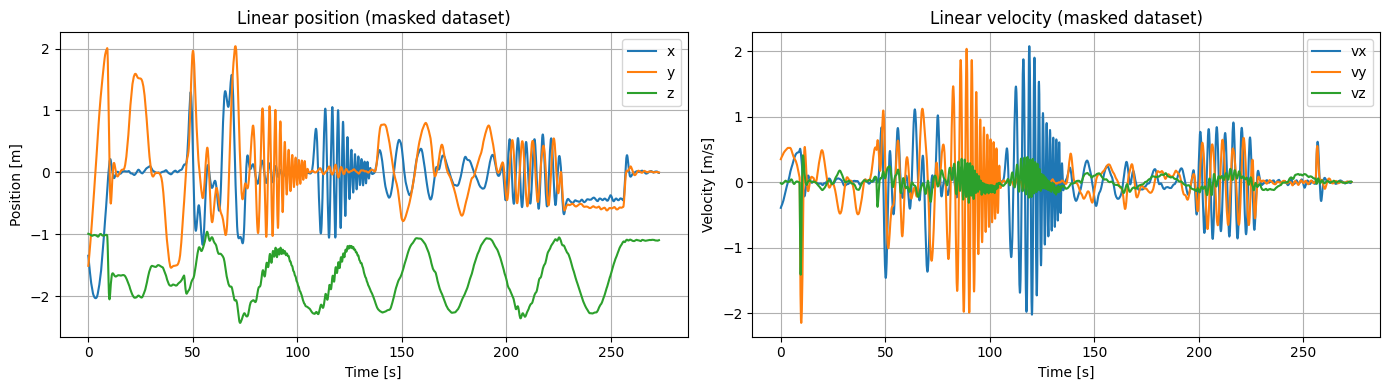

Dataset loaded from: dataset\dataset_masked.csv
Total samples: 13652
Train pairs: 10559, Val pairs: 2640
Test segments: [150, 150, 150]


In [4]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use masked dataset
DATASET_PATH = os.path.join("dataset", "dataset_masked.csv")
dataset_df = pd.read_csv(DATASET_PATH)
dataset_np = dataset_df.to_numpy(dtype=np.float32)

# Global normalization statistics from masked dataset
mean, std = get_mean_and_std(dataset_np)

# Split into train/val pool and fixed test windows
dt_candidates = dataset_np[:, 1]
dt_nominal = float(np.median(dt_candidates[dt_candidates > 0])) if np.any(dt_candidates > 0) else 0.2
data_test_segments, data_train_val = split_data(dataset_np, time_period=3, dt=dt_nominal, t0=25, t1=125, t2=220)

# Create pairs for train/val
pairs_curr, pairs_next = create_and_shuffle_pairs(data_train_val)
split_idx = int(0.8 * len(pairs_curr))
split_idx = min(max(split_idx, 1), len(pairs_curr) - 1)

train_data_current, val_data_current = pairs_curr[:split_idx], pairs_curr[split_idx:]
train_data_next, val_data_next = pairs_next[:split_idx], pairs_next[split_idx:]

X_train, X_train_next, U_train, U_train_next, dt_train = configure_training_and_validation_data(train_data_current, train_data_next)
X_val, X_val_next, U_val, U_val_next, dt_val = configure_training_and_validation_data(val_data_current, val_data_next)

# Keep only the 12-state used by physics/loss: [pos(3), euler(3), vel(3), ang_vel(3)]
X_train_phys = X_train[:, :12].float()
X_train_next_phys = X_train_next[:, :12].float()
X_val_phys = X_val[:, :12].float()
X_val_next_phys = X_val_next[:, :12].float()

U_train = U_train.float()
U_val = U_val.float()
dt_train = dt_train.float()
dt_val = dt_val.float()

# Quick visualization of masked data
time = dataset_np[:, 0]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(time, dataset_np[:, 2], label="x")
ax[0].plot(time, dataset_np[:, 3], label="y")
ax[0].plot(time, dataset_np[:, 4], label="z")
ax[0].set_title("Linear position (masked dataset)")
ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(time, dataset_np[:, 5], label="vx")
ax[1].plot(time, dataset_np[:, 6], label="vy")
ax[1].plot(time, dataset_np[:, 7], label="vz")
ax[1].set_title("Linear velocity (masked dataset)")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Velocity [m/s]")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Dataset loaded from: {DATASET_PATH}")
print(f"Total samples: {len(dataset_np)}")
print(f"Train pairs: {len(train_data_current)}, Val pairs: {len(val_data_current)}")
print(f"Test segments: {[seg.shape[0] for seg in data_test_segments]}")

**Step 5: Define Data-loss**

In [5]:
import torch
import torch.nn as nn
# from a_System_dynamics.system_dynamics import system_dynamics

_mse_loss = nn.MSELoss()

def data_loss(model, X_curr_NN, U_curr_NN, X_curr, X_next, dt,
              mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
              channel_weights=None, lambda_corr=0): # CHANGE HERE
    """
    model outputs only Δx_dot (correction).
    X_curr, X_next are in physical units.
    dt: (B,) or (B,1)
    """

    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # baseline physics derivative
    x_dot_phys = system_dynamics(X_curr, U_curr_NN, mass, inertia=inertia, g=g)  # (B,12)

    # NN correction in derivative space
    delta_x_dot = model(X_curr_NN, U_curr_NN)  # (B,12)

    # corrected derivative
    x_dot_total = x_dot_phys + delta_x_dot

    # integrate one Euler step
    X_next_pred = X_curr + dt * x_dot_total

    # Wrap angles before comparing (optional but recommended)
    # Compare roll/pitch/yaw with angle-wrapping safe representation:
    X_next_pred_wrapped = X_next_pred.clone()
    X_next_true_wrapped = X_next.clone()

    for idx in [3, 4, 5]:  # roll, pitch, yaw indices in your 12-state
        X_next_pred_wrapped[:, idx] = torch.atan2(torch.sin(X_next_pred[:, idx]), torch.cos(X_next_pred[:, idx]))
        X_next_true_wrapped[:, idx] = torch.atan2(torch.sin(X_next[:, idx]), torch.cos(X_next[:, idx]))

    # channel-wise MSE (to keep your weighting approach)
    per_channel_losses = torch.mean((X_next_pred_wrapped - X_next_true_wrapped) ** 2, dim=0)  # (12,)

    if channel_weights is None:
        cw = torch.ones(12, device=X_curr.device, dtype=X_curr.dtype)
    else:
        cw = channel_weights.to(device=X_curr.device, dtype=X_curr.dtype)

    loss_data = torch.sum(cw * per_channel_losses)

    # Optional: discourage huge corrections (PINN-ish regularization)
    loss_corr = torch.mean(delta_x_dot ** 2)

    total_loss = loss_data + lambda_corr * loss_corr
    return total_loss, {"loss_data": loss_data.detach(), "loss_corr": loss_corr.detach()}

**Step 6: Training and Validation**

Epoch 050/300 | train: 0.036093 | val: 0.035962
Epoch 100/300 | train: 0.023535 | val: 0.024447
Epoch 150/300 | train: 0.016549 | val: 0.017974
Epoch 200/300 | train: 0.012487 | val: 0.014134
Epoch 250/300 | train: 0.009674 | val: 0.011452
Epoch 300/300 | train: 0.007756 | val: 0.009609
Training complete.


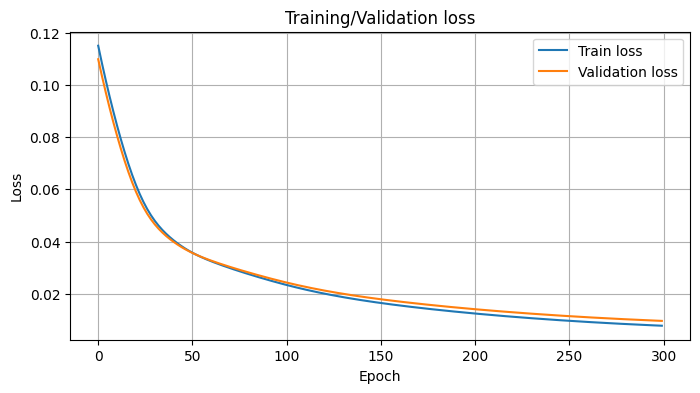

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


def build_nn_state_inputs(X_phys, mean_t, std_t):
    """
    Build NN state input using same structure as earlier helpers:
    [normalized pos(3), raw angles(3), normalized vel(3), normalized ang_vel(3)]
    """
    pos_norm = (X_phys[:, 0:3] - mean_t[0:3]) / std_t[0:3]
    angles = X_phys[:, 3:6]
    vel_norm = (X_phys[:, 6:9] - mean_t[3:6]) / std_t[3:6]
    ang_vel_norm = (X_phys[:, 9:12] - mean_t[6:9]) / std_t[6:9]
    return torch.cat([pos_norm, angles, vel_norm, ang_vel_norm], dim=1)


def rollout_step(model, X_phys, U_phys, dt, mean_t, std_t, mass=2.0, inertia=None, g=9.81):
    """
    Single rollout step with consistent representation handling.

    Inputs are physical units. Internally it builds NN features exactly as in training,
    predicts a correction in physical derivative units, computes baseline physics,
    and integrates one Euler step.
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    if inertia is None:
        inertia = torch.tensor([0.0217, 0.0217, 0.04], device=X_phys.device, dtype=X_phys.dtype)

    X_nn = build_nn_state_inputs(X_phys, mean_t, std_t)
    x_dot_phys = system_dynamics(X_phys, U_phys, mass=mass, inertia=inertia, g=g)
    delta_x_dot = model(X_nn, U_phys)
    X_next = X_phys + dt * (x_dot_phys + delta_x_dot)

    return X_next, x_dot_phys, delta_x_dot


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mean_t = torch.tensor(mean, dtype=torch.float32, device=device)
std_t = torch.tensor(std, dtype=torch.float32, device=device)

# Use NN-definition from Step 2
model = ResidualBModel(hidden_layers_size=[128, 128], activation_fn=nn.Tanh).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

X_train_phys_d = X_train_phys.to(device)
X_train_next_phys_d = X_train_next_phys.to(device)
U_train_d = U_train.to(device)
dt_train_d = dt_train.to(device)

X_val_phys_d = X_val_phys.to(device)
X_val_next_phys_d = X_val_next_phys.to(device)
U_val_d = U_val.to(device)
dt_val_d = dt_val.to(device)

X_train_nn = build_nn_state_inputs(X_train_phys_d, mean_t, std_t)
X_val_nn = build_nn_state_inputs(X_val_phys_d, mean_t, std_t)

channel_weights = torch.ones(12, device=device)
lambda_corr = 1e-4  # small regularization to prevent huge corrections
num_epochs = 300

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    train_loss, _ = data_loss(
        model=model,
        X_curr_NN=X_train_nn,
        U_curr_NN=U_train_d,
        X_curr=X_train_phys_d,
        X_next=X_train_next_phys_d,
        dt=dt_train_d,
        channel_weights=channel_weights,
        lambda_corr=lambda_corr,
    )
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss, _ = data_loss(
            model=model,
            X_curr_NN=X_val_nn,
            U_curr_NN=U_val_d,
            X_curr=X_val_phys_d,
            X_next=X_val_next_phys_d,
            dt=dt_val_d,
            channel_weights=channel_weights,
            lambda_corr=lambda_corr,
        )

    train_losses.append(float(train_loss.item()))
    val_losses.append(float(val_loss.item()))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{num_epochs} | train: {train_losses[-1]:.6f} | val: {val_losses[-1]:.6f}")

print("Training complete.")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training/Validation loss")
plt.grid(True)
plt.legend()
plt.show()

trained_model = model

**Step 6b: Closed-loop multi-step training (rollout loss)**

Closed-loop train windows: 3517, val windows: 877, horizon K=10
[CL] Epoch 025/200 | train: 0.064022 | val: 0.020974
[CL] Epoch 050/200 | train: 0.034647 | val: 0.018546
[CL] Epoch 075/200 | train: 0.022857 | val: 0.015547
[CL] Epoch 100/200 | train: 0.013181 | val: 0.013710
[CL] Epoch 125/200 | train: 0.009263 | val: 0.013651
[CL] Epoch 150/200 | train: 0.007503 | val: 0.013827
[CL] Epoch 175/200 | train: 0.006440 | val: 0.014415
[CL] Epoch 200/200 | train: 0.005767 | val: 0.014517
Closed-loop training complete.


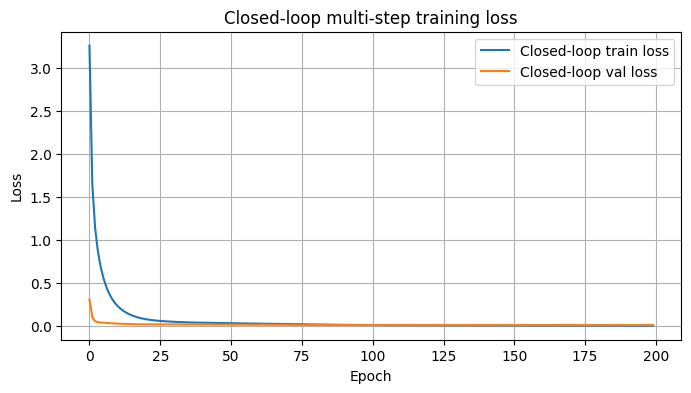

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Closed-loop training hyperparameters
K_rollout = 10          # unroll horizon
stride = 3              # window stride to reduce overlap
num_epochs_cl = 200
lr_cl = 5e-4
lambda_corr_cl = 1e-4
batch_size_cl = 64

def build_transition_tensors(seq_np):
    """
    Build one-step transitions from a contiguous sequence in raw dataset format.
    Returns tensors on the active device for the 12-state model.
    """
    curr = seq_np[:-1]
    nxt = seq_np[1:]
    X_curr, X_next, U_curr, _, dt = configure_training_and_validation_data(curr, nxt)

    X_curr_phys = X_curr[:, :12].float().to(device)
    X_next_phys = X_next[:, :12].float().to(device)
    U_curr = U_curr.float().to(device)
    dt = dt.float().to(device)
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    return X_curr_phys, X_next_phys, U_curr, dt

def build_rollout_windows(X_curr, X_next, U_curr, dt, K=10, stride=1):
    """
    Build windows for closed-loop unrolling.
    x0: (Nw,12), U_seq: (Nw,K,4), dt_seq: (Nw,K,1), X_tgt: (Nw,K,12)
    """
    n_steps = X_curr.shape[0]
    n_windows = n_steps - K + 1
    if n_windows <= 0:
        raise ValueError(f"Not enough samples ({n_steps}) for K={K} rollout windows.")

    x0_list, u_seq_list, dt_seq_list, x_tgt_list = [], [], [], []
    for s in range(0, n_windows, stride):
        x0_list.append(X_curr[s])
        u_seq_list.append(U_curr[s:s + K])
        dt_seq_list.append(dt[s:s + K])
        x_tgt_list.append(X_next[s:s + K])

    x0 = torch.stack(x0_list, dim=0)
    U_seq = torch.stack(u_seq_list, dim=0)
    dt_seq = torch.stack(dt_seq_list, dim=0)
    X_tgt = torch.stack(x_tgt_list, dim=0)
    return x0, U_seq, dt_seq, X_tgt

def rollout_unroll(model, x0, U_seq, dt_seq):
    """
    Closed-loop unroll using rollout_step.
    x0: (B,12), U_seq: (B,K,4), dt_seq: (B,K,1)
    returns X_pred_seq: (B,K,12)
    """
    xk = x0
    preds = []
    K = U_seq.shape[1]

    for k in range(K):
        uk = U_seq[:, k, :]
        hk = dt_seq[:, k, :]
        xk, _, _ = rollout_step(
            model=model,
            X_phys=xk,
            U_phys=uk,
            dt=hk,
            mean_t=mean_t,
            std_t=std_t,
            mass=2.0,
            inertia=torch.tensor([0.0217, 0.0217, 0.04], device=device),
            g=9.81,
        )
        preds.append(xk.unsqueeze(1))

    return torch.cat(preds, dim=1)

def closed_loop_loss(X_pred_seq, X_tgt_seq, channel_weights=None, lambda_corr=0.0):
    """
    Multi-step trajectory loss with angle wrapping and optional channel weighting.
    Inputs shape: (B,K,12)
    """
    # Build error without in-place writes to keep autograd graph valid.
    err = X_pred_seq - X_tgt_seq
    ang_err = torch.atan2(torch.sin(err[:, :, 3:6]), torch.cos(err[:, :, 3:6]))
    err_wrapped = torch.cat([err[:, :, 0:3], ang_err, err[:, :, 6:12]], dim=2)

    sq_err = err_wrapped ** 2  # (B,K,12)
    per_channel = torch.mean(sq_err, dim=(0, 1))  # (12,)

    if channel_weights is None:
        cw = torch.ones(12, device=err_wrapped.device, dtype=err_wrapped.dtype)
    else:
        cw = channel_weights.to(device=err_wrapped.device, dtype=err_wrapped.dtype)

    loss_data = torch.sum(cw * per_channel)
    # No direct correction tensor here, keep API-compatible regularizer as 0.
    loss_corr = torch.tensor(0.0, device=err_wrapped.device, dtype=err_wrapped.dtype)

    return loss_data + lambda_corr * loss_corr

# Use contiguous split for rollout training/validation
split_seq_idx = int(0.8 * len(data_train_val))
train_seq = data_train_val[:split_seq_idx]
val_seq = data_train_val[split_seq_idx:]

Xc_tr, Xn_tr, U_tr, dt_tr = build_transition_tensors(train_seq)
Xc_va, Xn_va, U_va, dt_va = build_transition_tensors(val_seq)

x0_tr, Useq_tr, dtseq_tr, Xtgt_tr = build_rollout_windows(Xc_tr, Xn_tr, U_tr, dt_tr, K=K_rollout, stride=stride)
x0_va, Useq_va, dtseq_va, Xtgt_va = build_rollout_windows(Xc_va, Xn_va, U_va, dt_va, K=K_rollout, stride=stride)

print(f"Closed-loop train windows: {x0_tr.shape[0]}, val windows: {x0_va.shape[0]}, horizon K={K_rollout}")

model_cl = ResidualBModel(hidden_layers_size=[128, 128], activation_fn=nn.Tanh).to(device)
optimizer_cl = optim.Adam(model_cl.parameters(), lr=lr_cl)
channel_weights_cl = torch.ones(12, device=device)

train_losses_cl, val_losses_cl = [], []

for epoch in range(num_epochs_cl):
    model_cl.train()
    perm = torch.randperm(x0_tr.shape[0], device=device)
    epoch_train_loss = 0.0

    for start in range(0, x0_tr.shape[0], batch_size_cl):
        idx = perm[start:start + batch_size_cl]
        x0_b = x0_tr[idx]
        U_b = Useq_tr[idx]
        dt_b = dtseq_tr[idx]
        X_tgt_b = Xtgt_tr[idx]

        optimizer_cl.zero_grad()
        X_pred_b = rollout_unroll(model_cl, x0_b, U_b, dt_b)
        loss_b = closed_loop_loss(X_pred_b, X_tgt_b, channel_weights=channel_weights_cl, lambda_corr=lambda_corr_cl)
        loss_b.backward()
        optimizer_cl.step()
        epoch_train_loss += float(loss_b.item())

    epoch_train_loss /= max(1, (x0_tr.shape[0] + batch_size_cl - 1) // batch_size_cl)
    train_losses_cl.append(epoch_train_loss)

    model_cl.eval()
    with torch.no_grad():
        X_pred_va = rollout_unroll(model_cl, x0_va, Useq_va, dtseq_va)
        val_loss = closed_loop_loss(X_pred_va, Xtgt_va, channel_weights=channel_weights_cl, lambda_corr=lambda_corr_cl)
        val_losses_cl.append(float(val_loss.item()))

    if (epoch + 1) % 25 == 0:
        print(f"[CL] Epoch {epoch+1:03d}/{num_epochs_cl} | train: {train_losses_cl[-1]:.6f} | val: {val_losses_cl[-1]:.6f}")

print("Closed-loop training complete.")

plt.figure(figsize=(8, 4))
plt.plot(train_losses_cl, label="Closed-loop train loss")
plt.plot(val_losses_cl, label="Closed-loop val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Closed-loop multi-step training loss")
plt.grid(True)
plt.legend()
plt.show()

# Use this model for downstream tests if desired
trained_model = model_cl

**Step 7: Test trained model (Plot velocity error)**

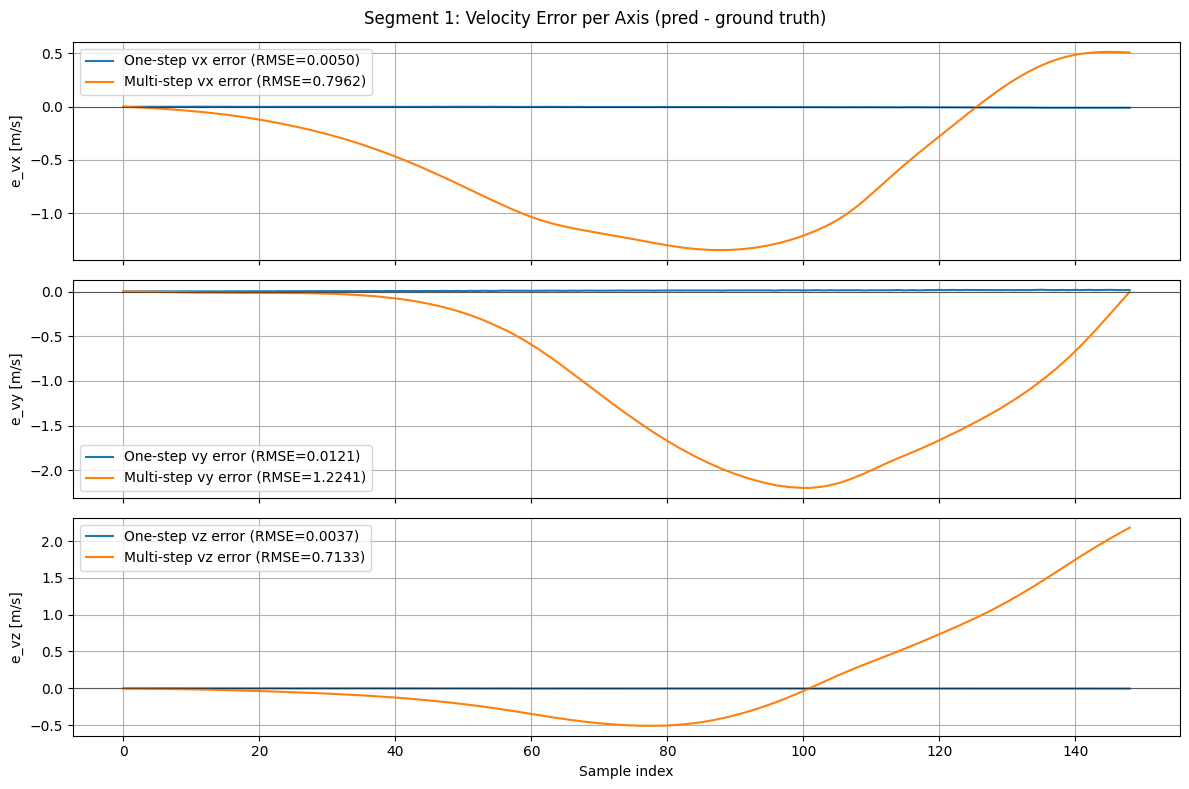

Segment 1 velocity RMSE | one-step [vx, vy, vz]=[0.005038, 0.012067, 0.003693] | multi-step [vx, vy, vz]=[0.796159, 1.224096, 0.713276]


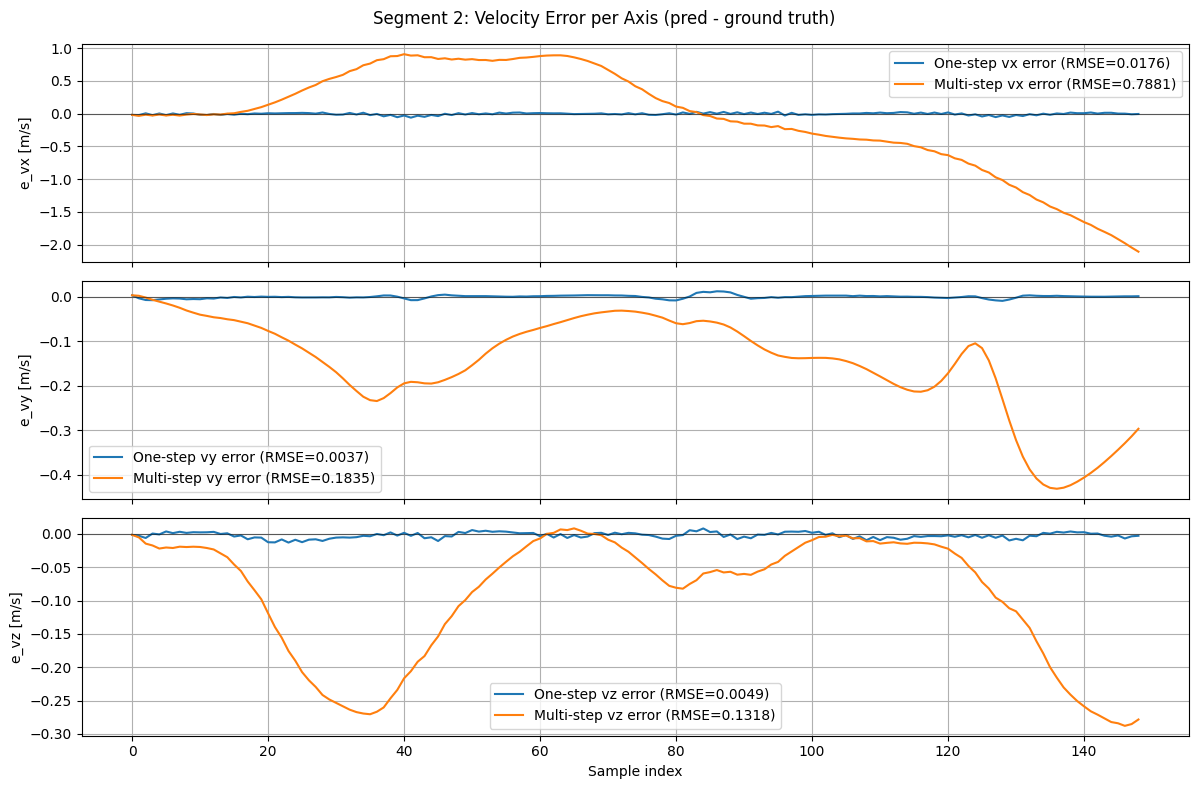

Segment 2 velocity RMSE | one-step [vx, vy, vz]=[0.017647, 0.003714, 0.004902] | multi-step [vx, vy, vz]=[0.788124, 0.183539, 0.131801]


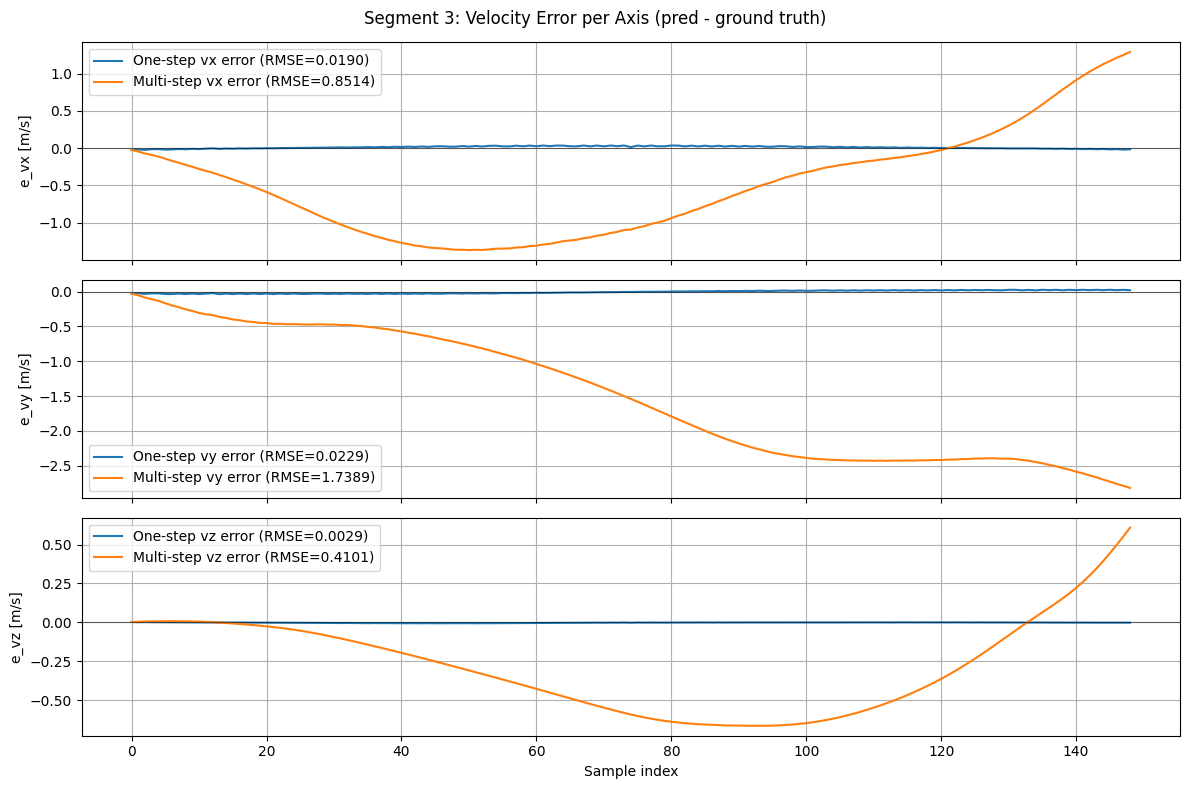

Segment 3 velocity RMSE | one-step [vx, vy, vz]=[0.018958, 0.022856, 0.002867] | multi-step [vx, vy, vz]=[0.851375, 1.738863, 0.410134]


In [8]:
import torch
import matplotlib.pyplot as plt

# Evaluate velocity error per axis on each test segment (one-step vs multi-step)
trained_model.eval()

for i, seg in enumerate(data_test_segments, start=1):
    if seg.shape[0] < 3:
        continue

    # Consecutive (current, next) pairs without shuffling for trajectory-style analysis
    seg_curr = seg[:-1]
    seg_next = seg[1:]

    X_seg, X_seg_next, U_seg, _, dt_seg = configure_training_and_validation_data(seg_curr, seg_next)
    X_seg_phys = X_seg[:, :12].float().to(device)
    X_seg_next_phys = X_seg_next[:, :12].float().to(device)
    U_seg = U_seg.float().to(device)
    dt_seg = dt_seg.float().to(device)

    with torch.no_grad():
        # ---------- One-step (teacher forcing) ----------
        X_pred_onestep, _, _ = rollout_step(
            model=trained_model,
            X_phys=X_seg_phys,
            U_phys=U_seg,
            dt=dt_seg,
            mean_t=mean_t,
            std_t=std_t,
            mass=2.0,
            inertia=torch.tensor([0.0217, 0.0217, 0.04], device=device),
            g=9.81,
        )

        # ---------- Multi-step (recursive rollout) ----------
        if dt_seg.ndim == 1:
            dt_seg = dt_seg.view(-1, 1)

        xk = X_seg_phys[0:1].clone()
        X_pred_multistep_list = []

        for k in range(U_seg.shape[0]):
            uk = U_seg[k:k+1]
            hk = dt_seg[k:k+1]
            xk, _, _ = rollout_step(
                model=trained_model,
                X_phys=xk,
                U_phys=uk,
                dt=hk,
                mean_t=mean_t,
                std_t=std_t,
                mass=2.0,
                inertia=torch.tensor([0.0217, 0.0217, 0.04], device=device),
                g=9.81,
            )
            X_pred_multistep_list.append(xk.clone())

        X_pred_multistep = torch.cat(X_pred_multistep_list, dim=0)

    # Velocity errors per axis: prediction - ground truth (x_{k+1} comparison)
    vel_err_onestep = (X_pred_onestep[:, 6:9] - X_seg_next_phys[:, 6:9]).detach().cpu().numpy()
    vel_err_multistep = (X_pred_multistep[:, 6:9] - X_seg_next_phys[:, 6:9]).detach().cpu().numpy()

    rmse_onestep = torch.sqrt(torch.mean((X_pred_onestep[:, 6:9] - X_seg_next_phys[:, 6:9]) ** 2, dim=0)).detach().cpu().numpy()
    rmse_multistep = torch.sqrt(torch.mean((X_pred_multistep[:, 6:9] - X_seg_next_phys[:, 6:9]) ** 2, dim=0)).detach().cpu().numpy()

    # Plot vx, vy, vz errors
    axis_labels = ["vx", "vy", "vz"]
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    for ax_idx in range(3):
        axes[ax_idx].plot(vel_err_onestep[:, ax_idx], label=f"One-step {axis_labels[ax_idx]} error (RMSE={rmse_onestep[ax_idx]:.4f})")
        axes[ax_idx].plot(vel_err_multistep[:, ax_idx], label=f"Multi-step {axis_labels[ax_idx]} error (RMSE={rmse_multistep[ax_idx]:.4f})")
        axes[ax_idx].axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
        axes[ax_idx].set_ylabel(f"e_{axis_labels[ax_idx]} [m/s]")
        axes[ax_idx].grid(True)
        axes[ax_idx].legend()

    axes[-1].set_xlabel("Sample index")
    fig.suptitle(f"Segment {i}: Velocity Error per Axis (pred - ground truth)")
    plt.tight_layout()
    plt.show()

    print(
        f"Segment {i} velocity RMSE | "
        f"one-step [vx, vy, vz]=[{rmse_onestep[0]:.6f}, {rmse_onestep[1]:.6f}, {rmse_onestep[2]:.6f}] | "
        f"multi-step [vx, vy, vz]=[{rmse_multistep[0]:.6f}, {rmse_multistep[1]:.6f}, {rmse_multistep[2]:.6f}]"
    )

**Step 8: Plot position error in 3D (Ground truth vs onestep vs multistep)**

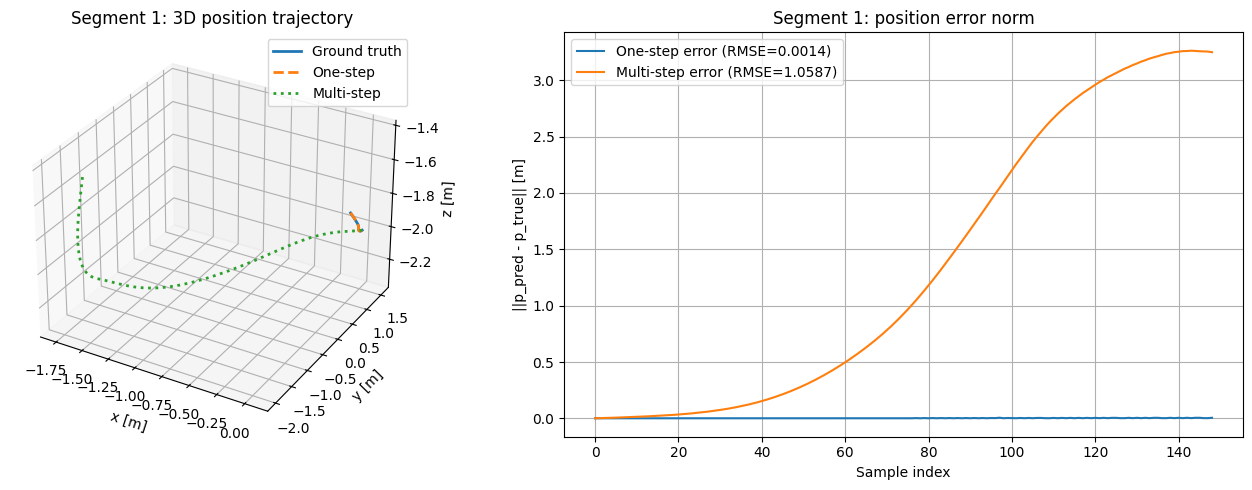

Segment 1 position RMSE -> one-step: 0.001389, multi-step: 1.058745


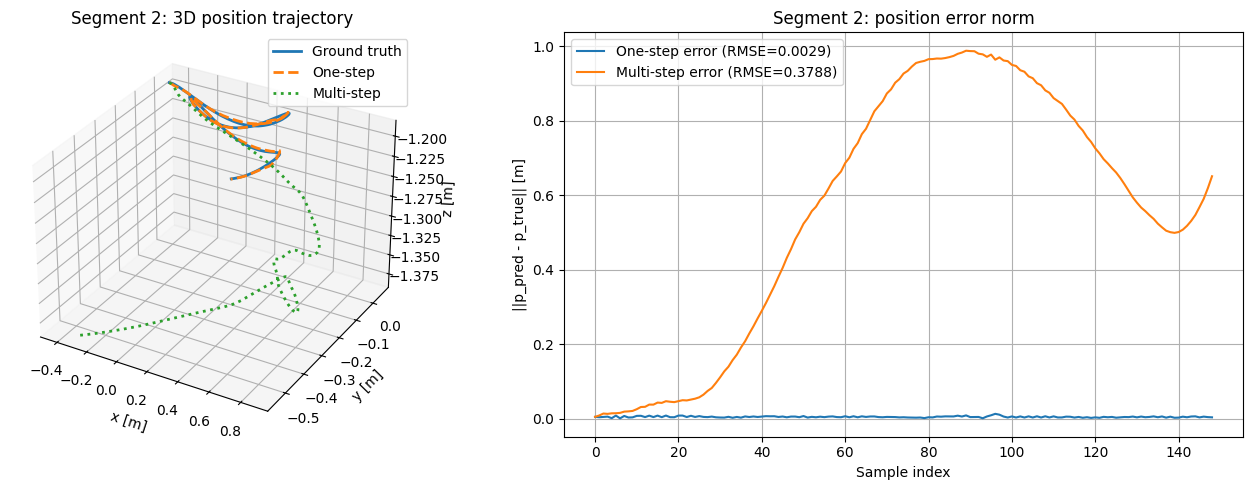

Segment 2 position RMSE -> one-step: 0.002883, multi-step: 0.378799


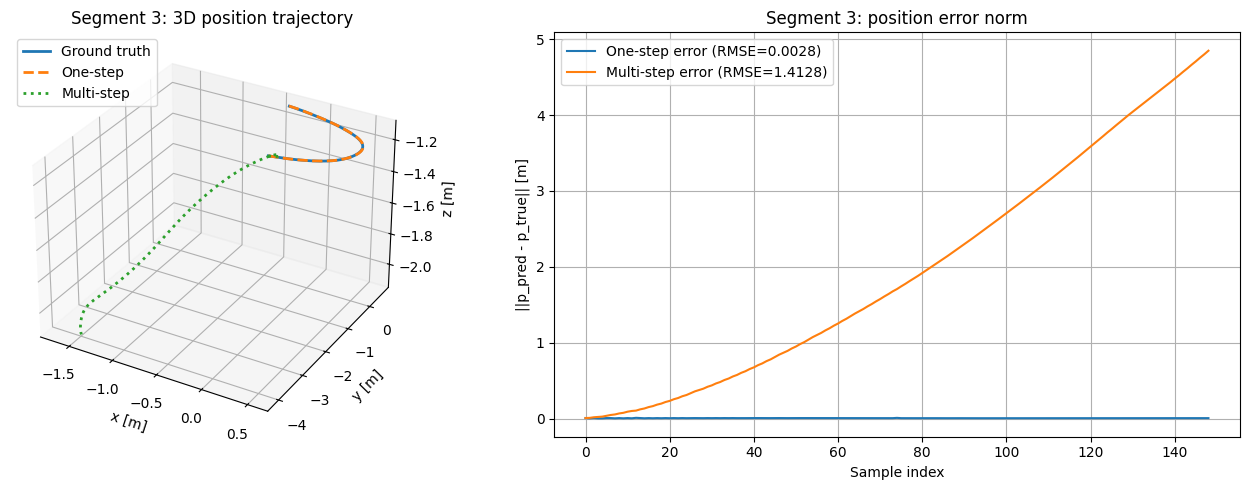

Segment 3 position RMSE -> one-step: 0.002787, multi-step: 1.412798


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

trained_model.eval()

for seg_idx, seg in enumerate(data_test_segments, start=1):
    if seg.shape[0] < 3:
        continue

    # Build consecutive pairs for one-step predictions
    seg_curr = seg[:-1]
    seg_next = seg[1:]
    X_seg, X_seg_next, U_seg, _, dt_seg = configure_training_and_validation_data(seg_curr, seg_next)

    X_seg_phys = X_seg[:, :12].float().to(device)
    X_seg_next_phys = X_seg_next[:, :12].float().to(device)
    U_seg = U_seg.float().to(device)
    dt_seg = dt_seg.float().to(device)

    with torch.no_grad():
        # ---------- One-step (teacher forcing): x_{k+1} from true x_k ----------
        X_pred_onestep, _, _ = rollout_step(
            model=trained_model,
            X_phys=X_seg_phys,
            U_phys=U_seg,
            dt=dt_seg,
            mean_t=mean_t,
            std_t=std_t,
            mass=2.0,
            inertia=torch.tensor([0.0217, 0.0217, 0.04], device=device),
            g=9.81,
        )

        # ---------- Multi-step (recursive rollout): x_{k+1} from predicted x_k ----------
        xk = X_seg_phys[0:1].clone()  # start from true initial state
        X_pred_multistep_list = []

        if dt_seg.ndim == 1:
            dt_seg = dt_seg.view(-1, 1)

        for k in range(U_seg.shape[0]):
            uk = U_seg[k:k+1]
            hk = dt_seg[k:k+1]
            xk, _, _ = rollout_step(
                model=trained_model,
                X_phys=xk,
                U_phys=uk,
                dt=hk,
                mean_t=mean_t,
                std_t=std_t,
                mass=2.0,
                inertia=torch.tensor([0.0217, 0.0217, 0.04], device=device),
                g=9.81,
            )
            X_pred_multistep_list.append(xk.clone())

        X_pred_multistep = torch.cat(X_pred_multistep_list, dim=0)

    # Position trajectories
    gt_pos = seg[:, 2:5]  # full segment ground-truth positions (N+1 points)
    onestep_pos = np.vstack([
        X_seg_phys[0, 0:3].detach().cpu().numpy(),
        X_pred_onestep[:, 0:3].detach().cpu().numpy(),
    ])
    multistep_pos = np.vstack([
        X_seg_phys[0, 0:3].detach().cpu().numpy(),
        X_pred_multistep[:, 0:3].detach().cpu().numpy(),
    ])

    # Position errors (compare x_{k+1})
    err_onestep = torch.linalg.norm(X_pred_onestep[:, 0:3] - X_seg_next_phys[:, 0:3], dim=1).detach().cpu().numpy()
    err_multistep = torch.linalg.norm(X_pred_multistep[:, 0:3] - X_seg_next_phys[:, 0:3], dim=1).detach().cpu().numpy()

    rmse_onestep = float(torch.sqrt(torch.mean((X_pred_onestep[:, 0:3] - X_seg_next_phys[:, 0:3]) ** 2)).item())
    rmse_multistep = float(torch.sqrt(torch.mean((X_pred_multistep[:, 0:3] - X_seg_next_phys[:, 0:3]) ** 2)).item())

    # -------- Plot --------
    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], label="Ground truth", linewidth=2)
    ax1.plot(onestep_pos[:, 0], onestep_pos[:, 1], onestep_pos[:, 2], "--", label="One-step", linewidth=2)
    ax1.plot(multistep_pos[:, 0], multistep_pos[:, 1], multistep_pos[:, 2], ":", label="Multi-step", linewidth=2)
    ax1.set_title(f"Segment {seg_idx}: 3D position trajectory")
    ax1.set_xlabel("x [m]")
    ax1.set_ylabel("y [m]")
    ax1.set_zlabel("z [m]")
    ax1.legend()

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(err_onestep, label=f"One-step error (RMSE={rmse_onestep:.4f})")
    ax2.plot(err_multistep, label=f"Multi-step error (RMSE={rmse_multistep:.4f})")
    ax2.set_title(f"Segment {seg_idx}: position error norm")
    ax2.set_xlabel("Sample index")
    ax2.set_ylabel("||p_pred - p_true|| [m]")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Segment {seg_idx} position RMSE -> one-step: {rmse_onestep:.6f}, multi-step: {rmse_multistep:.6f}")

$$\mathcal{L}N = \sum{t} \sum_{k=1}^{N} | x_{t+k} - \hat{x}_{t+k} |^2$$

$$\mathcal{L}1 = \sum_t | x{t+1} - \hat{x}_{t+1} |^2$$